## Dimensionality Reduction with PCA

***Week 5 - Day 3***

**Step 1: Scale a high-dimensional provided dataset with StandardScaler.**

In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  

X_scaled = StandardScaler().fit_transform(X)

In [7]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [15]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

**Step 2: Fit PCA and plot the cumulative explained variance against the number of components.**

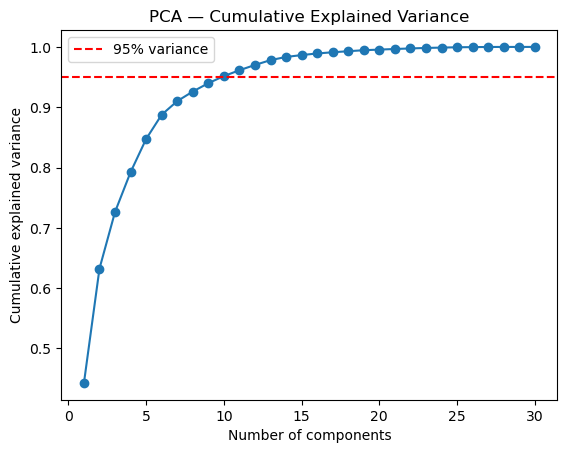

In [9]:
pca = PCA()
pca.fit(X_scaled_df)

cumulative_variance = pca.explained_variance_ratio_.cumsum()

plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.95, color="red", linestyle="--", label="95% variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA — Cumulative Explained Variance")
plt.legend()
plt.show()

We fit PCA on all 30 scaled features to see how much information (variance) each component keeps. The plot shows cumulative variance as we add more components. The red line marks 95% — our target. The curve crosses 95% at around 10 components, meaning we can reduce 30 features down to about 10 and still keep most of the original information.

In [16]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]
1.0000000000000002


This shows how much variance (information) each of the 30 components captures on its own. Component 1 explains about 44% of the total variance, Component 2 about 19%, and each following component adds less and less. All 30 components together add up to 100%, since no information is lost — we just changed the axes. This confirms why the first few components matter most, and why keeping around 10 components is enough to preserve most of the useful information.

**Step 3: Choose the number of components that retains ~95% of the variance and justify it.**

In [12]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"componant of 95 variance: {n_components_95}")

componant of 95 variance: 10


10 components retain about 95% of the total variance in the data. This means we can reduce the dataset from 30 features to just 10, with only a small loss of information. This makes the data easier to work with while still keeping almost everything that matters.

**Step 4: Reduce the data to 2 components and produce a 2D scatter plot, coloring points by a known group 
if available.**

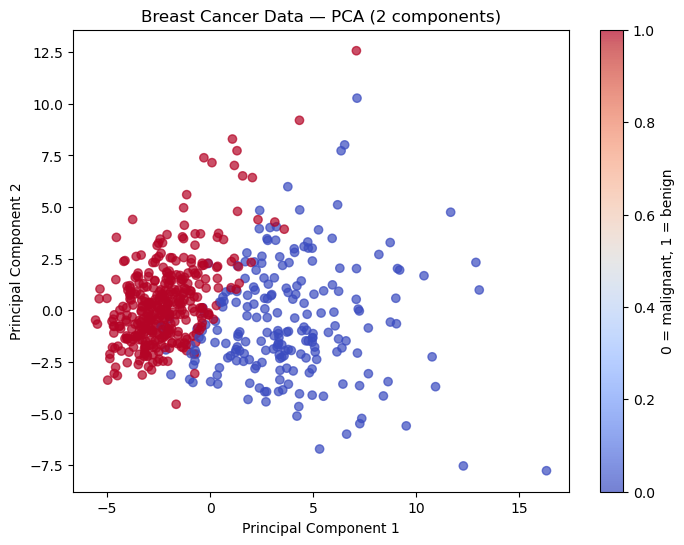

In [13]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled_df)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Breast Cancer Data — PCA (2 components)")
plt.colorbar(label="0 = malignant, 1 = benign")
plt.show()

**Step 5: Document what the reduction preserved and what it cost in Markdown.**

Reducing 30 features to just 2 components keeps only about 60% of the total variance (much less than the 95% we get with 10 components). Despite this big reduction, the 2D plot still shows a clear separation between malignant and benign tumors, mostly along Principal Component 1. This shows PCA can capture the most important pattern in the data even with very few components — but for a full model, we'd want the ~10 components from Step 3 to keep more information.